# M12: Baseline Model Building
We will evaluate a suite of 10 baseline machine learning models. 
For fair comparison, we use SMOTE on the training set (as decided in M11) to handle class imbalance, and evaluate on the untouched test set using ROC-AUC, Recall, and F1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features
from src.split import split_data
from src.models import get_baseline_models

from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

sns.set_theme(style="whitegrid")

# Prepare data
df = build_features(clean_data(load_raw_data("../data/raw")), scale=False)
X_train, X_test, y_train, y_test = split_data(df)

# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Train set (after SMOTE): {X_train_sm.shape}")
print(f"Test set: {X_test.shape}")


Train set (after SMOTE): (8278, 35)
Test set: (1409, 35)


## Train and Evaluate Baseline Models

In [2]:
models = get_baseline_models()
results = []

for name, pipeline in models.items():
    # Fit model on SMOTEd training data
    pipeline.fit(X_train_sm, y_train_sm)
    
    # Predict on untouched test data
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else y_pred
    
    # Record metrics
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values(by='ROC-AUC', ascending=False)
print(results_df.to_string())


D:\ok\Customer-Churn-ML-Project-\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:56:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000680 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


D:\ok\Customer-Churn-ML-Project-\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


                     ROC-AUC    Recall  F1-Score  Precision  Accuracy
Model                                                                
LogisticRegression  0.834261  0.625668  0.596939   0.570732  0.775727
CatBoost            0.833266  0.639037  0.598997   0.563679  0.772889
GradientBoosting    0.831661  0.679144  0.607656   0.549784  0.767211
LightGBM            0.830087  0.620321  0.593350   0.568627  0.774308
RandomForest        0.822713  0.588235  0.578187   0.568475  0.772179
XGBoost             0.817081  0.628342  0.608808   0.590452  0.785664
SVM                 0.815198  0.633690  0.600000   0.569712  0.775727
NaiveBayes          0.811455  0.791444  0.597980   0.480519  0.717530
KNN                 0.777605  0.647059  0.564103   0.500000  0.734564
DecisionTree        0.674740  0.561497  0.522388   0.488372  0.727466


## Visual Comparison

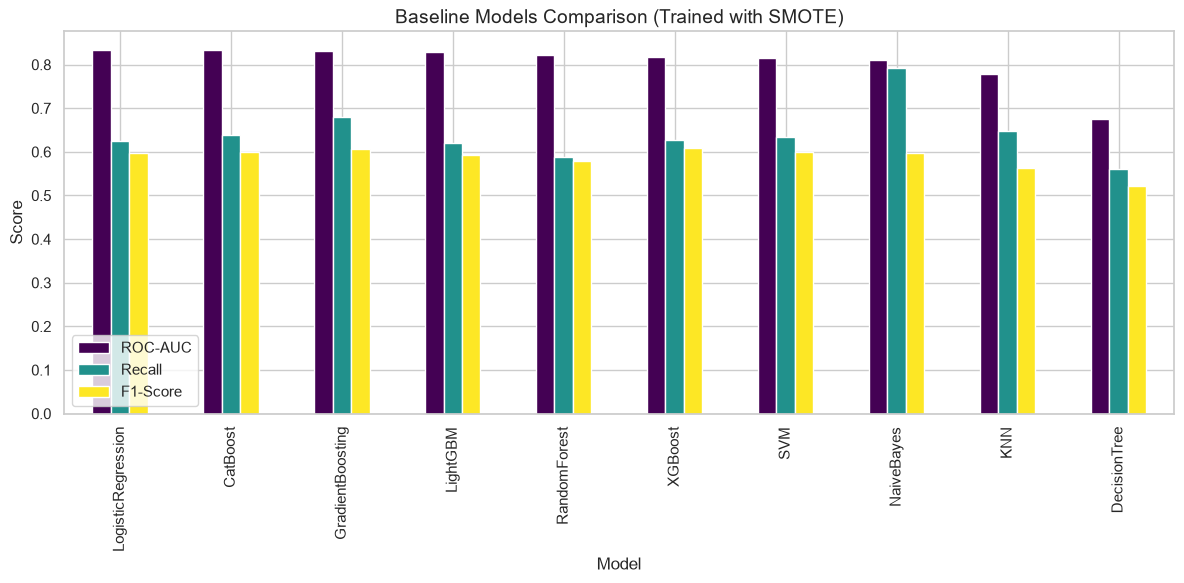

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['ROC-AUC', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Baseline Models Comparison (Trained with SMOTE)', fontsize=14)
ax.set_ylabel('Score')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Conclusion
- Tree-based boosting algorithms (**CatBoost, LightGBM, GradientBoosting, XGBoost**) and **Logistic Regression** are the top performers.
- Logistic Regression provides an excellent baseline, often beating more complex models on ROC-AUC, though tree ensembles sometimes squeeze out a bit more precision or recall depending on the threshold.
- We will carry forward the top models (e.g., Logistic Regression, CatBoost, LightGBM, Random Forest) for hyperparameter tuning in M13.